In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy
import os

In [5]:
# read in site metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/flows/seasonal/40_50yrs/40plus.csv")
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)


In [6]:
subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]

subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                                  geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')


In [7]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]
catchments_df.index = catchments_df['SITE']


In [5]:
std_x = 0.005e7
std_y = 0

text_offsets = {
1: (-std_x, std_y),  2: (std_x, std_y),  3: (0.004e7, std_y), 4: (-0.008e7, std_y), 5: (-0.008e7, std_y), 6: (std_x, std_y),
7: (std_x, std_y), 8: (-std_x, 0.02e6), 9: (0.002e7, 0.03e6),10: (-0.007e7, std_y), 11: (0.003e7, 0.04e6),
12: (0.004e7, std_y+0.03e6), 13: (0.004e7, std_y), 14: (std_x, std_y), 15: (-0.007e7, 0.01e6), 16: (-0.007e7, std_y),
17: (std_x, std_y), 18: (0, -0.06e6),   19: (-std_x, -0.06e6), 20: (-0.007e7, -0.03e6), 21: (0.002e7, -0.03e6),
22: (-0.007e7, std_y), 23: (-0.007e7, std_y), 24: (0.003e7, std_y),   25: (0.003e7, -0.04e6), 26: (0, 0.02e6),
27: (0.004e7, 0.03e6),  28: (-0.007e7, std_y), 29: (std_x, std_y),   30: (-0.007e7, std_y), 31: (0.003e7, 0.02e6), 
32: (0.005e7, 0.03e6), 33: (0.004e7, 0.01e6),  34: (std_x, std_y),   35: (0.002e7, -0.03e6), 36: (0, -0.03e6), 37: (0.002e7, std_y),
38: (0.003e7, -0.01e6),  39: (-0.007e7, 0.01e6), 40: (0.004e7, 0.02e6),  41: (0.002e7, -0.03e6), 42: (0.002e7, -0.03e6), 43: (0.002e7, -0.03e6),
44: (0.002e7, -0.03e6),  45: (0.002e7, -0.03e6),  46: (0.002e7, -0.03e6),  47: (-0.001e7, -0.04e6), 48: (0.002e7, -0.03e6), 49: (0.002e7, -0.03e6),
50: (0.002e7, -0.03e6),  51: (0.002e7, -0.03e6),  52: (0.002e7, -0.03e6),   53: (0.002e7, -0.03e6)
}


(-6000000, -4000000)

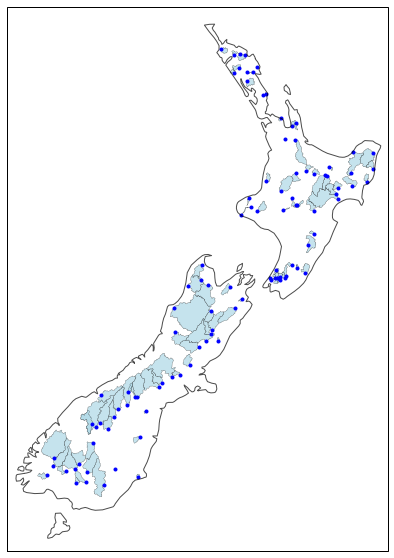

In [10]:
from matplotlib.image import imread

# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, ax = plt.subplots(figsize=(12,10),subplot_kw={'projection': crs})#,gridspec_kw={'width_ratios': [3, 1]})

catchments_df_ae.plot(ax=ax,color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.7)
meta_df_ae.plot(ax=ax,color='blue',marker='.',)#fontsize=14)

ax.coastlines(resolution='50m', color='black', linewidth=1, alpha=0.7)

ax.set_xlim([1.85e7,1.99e7])
ax.set_ylim([-6000000,-4000000])
